## Assignment_Week5_Part 2 ANA540 Final project 

**Instructions:**

- Please submit your work as either a .ipynb notebook file or a PDF file on Blackboard.

- Please make sure your name is included either in the file name or clearly written in your assignment.


**This assignment has two parts - first, implementing decision trees, random forests, and GBRT (GBRT is optional) on the heart disease dataset. Second, we will continue with our final project. This week, we need to complete data preprocessing. Then you can choose to complete Model Selection and Training and Model Preliminary Evaluation (you can also complete these two tasks next week). In the final week, we will only have the final project assignment to finish the remaining parts, such as model optimization and final evaluation.**

<br>

## Part 2: ANA540 Final project

**Goal**: Last week, we identified our dataset and conducted exploratory data analysis. This week, we'll continue and complete the data preprocessing phase, followed by Model Selection and Training, and then move on to Model Preliminary Evaluation.

**I suggest you continue with the new parts of this project in your previous assignment. Please make sure to adjust the assignment's title and the headings for each section to ensure clarity.**

In [19]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
from sklearn.model_selection import train_test_split 


os.chdir('/Users/nkohei/Workspace/plaize/airbnb/ocp_analysis')
df = pd.read_csv('df_final.csv')
print(df.head())

               room_id  occupancy_rate  propertyType_major_Entire home  \
0  1288180664022835353        0.433333                            True   
1  1342381500367926145        0.900000                           False   
2  1302716270088739688        0.500000                            True   
3             33020852        0.466667                           False   
4   917140594942569847        0.700000                            True   

   propertyType_major_Entire rental unit  propertyType_major_Entire villa  \
0                                  False                            False   
1                                  False                            False   
2                                  False                            False   
3                                  False                            False   
4                                  False                            False   

   propertyType_major_Other  propertyType_major_Private room in home  \
0                   

In [20]:
li_columns = ['room_id', 'occupancy_rate', 'propertyType_major_Entire home',
'propertyType_major_Entire rental unit',
'propertyType_major_Entire villa', 'propertyType_major_Other',
'propertyType_major_Private room in home',
'propertyType_major_Private room in ryokan',
'propertyType_major_Room in hotel', 'cancellationPolicies_Flexible',
'cancellationPolicies_Moderate', 'cancellationPolicies_Non-refundable',
'cancellationPolicies_Refundable', 'cancellationPolicies_Strict',
'rating.accuracy', 'rating.checking', 'rating.cleanliness',
'rating.communication', 'rating.location', 'rating.value',
'rating.guestSatisfaction', 'rating.reviewsCount', 'host.isSuperHost',
'host.isVerified', 'host.ratingCount', 'host.ratingAverage',
'host.timeAsHost.months', 'host.timeAsHost.years', 'price.price',
'guest', 'bedroom', 'bed', 'response_rate', 'distance_km', 'is_area']

df = df[li_columns]

df.head()

,room_id,occupancy_rate,propertyType_major_Entire home,propertyType_major_Entire rental unit,propertyType_major_Entire villa,propertyType_major_Other,propertyType_major_Private room in home,propertyType_major_Private room in ryokan,propertyType_major_Room in hotel,cancellationPolicies_Flexible,...,host.ratingAverage,host.timeAsHost.months,host.timeAsHost.years,price.price,guest,bedroom,bed,response_rate,distance_km,is_area
0,1288180664022835353,0.433333,True,False,False,False,False,False,False,False,...,4.91,5.0,3.0,506.0,4.0,1.0,2.0,100.0,1.649111,True
1,1342381500367926145,0.900000,False,False,False,False,True,False,False,True,...,0.00,0.0,0.0,51.0,NaN,2.0,2.0,100.0,0.352698,True
2,1302716270088739688,0.500000,True,False,False,False,False,False,False,False,...,4.87,2.0,0.0,198.0,7.0,3.0,2.0,100.0,0.764461,True
3,33020852,0.466667,False,False,False,True,False,False,False,False,...,NaN,NaN,NaN,133.0,4.0,1.0,3.0,NaN,0.659755,True
4,917140594942569847,0.700000,True,False,False,False,False,False,False,False,...,4.78,6.0,1.0,312.0,6.0,4.0,3.0,100.0,0.200439,True


### Task 1: Data Preprocessing

Before modeling, it's imperative to conduct necessary preprocessing on your dataset to ensure it's optimally formatted for machine learning algorithms. Data preprocessing aims to handle missing values, clean outliers, encode categorical features, and transform the data into a structure amenable to machine learning models.

#### 1. Train-Test Split

It's advisable to split the data into training and test sets before applying any feature scaling, to avoid information leakage and ensure the test set accurately represents future unseen data. 

- **Data Split**: Use `train_test_split` to split your data. A common practice is to allocate approximately 70-80% of the data to the training set and the remainder to the testing set.
- **Random State**: Set a random state for reproducibility. This ensures you get the same split every time.
- **Time Series**: In the case of time series data, ensure to split the data based on time, avoiding randomization. This preserves the chronological order, which is vital for the integrity of time series analysis.
- **Sizing**: After splitting, verify the sizes of your train and test sets to ensure they are appropriate for your modeling needs.

In [21]:
print('before split: ', df.shape)

y = df['occupancy_rate']
X = df.drop(['occupancy_rate','room_id'], axis=1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print('after split: ', X_train.shape, X_test.shape, y_train.shape, y_test.shape)

before split:  (1287, 35)
after split:  (1029, 33) (258, 33) (1029,) (258,)


#### 2. Data Preprocessing

As you embark on preprocessing, consider that not every step may be necessary for your specific dataset. The choice of preprocessing steps should be informed by your data's characteristics, the requirements of your intended models, and your project's unique goals. Following are some aspects to consider for preprocessing your dataset:

- **Handling Missing Values**: Opt for an appropriate strategy such as deletion or imputation, considering the extent and nature of the missing data.
- **Outlier Treatment**: After determining whether they represent true values or errors, decide on a treatment for outliers—this could involve deletion or correction.
- **Categorical Feature Encoding**: Based on your dataset, decide whether one-hot encoding or another encoding method is necessary for categorical features. hint: for one-hot encoding, you can use `pd.get_dummies` in Pandas.
- **Feature Construction**: If needed, consider constructing new features using methods such as PCA (to be discussed in upcoming sessions).
- **Feature Selection**: If needed, undertake feature selection to eliminate redundant features (e.g.,correlation analysis).


In [22]:
X_train.isnull().sum()

propertyType_major_Entire home                 0
propertyType_major_Entire rental unit          0
propertyType_major_Entire villa                0
propertyType_major_Other                       0
propertyType_major_Private room in home        0
propertyType_major_Private room in ryokan      0
propertyType_major_Room in hotel               0
cancellationPolicies_Flexible                  0
cancellationPolicies_Moderate                  0
cancellationPolicies_Non-refundable            0
cancellationPolicies_Refundable                0
cancellationPolicies_Strict                    0
rating.accuracy                              144
rating.checking                              144
rating.cleanliness                           144
rating.communication                         144
rating.location                              144
rating.value                                 144
rating.guestSatisfaction                     143
rating.reviewsCount                          143
host.isSuperHost    

In [46]:
X_tr_drop_idx = ~X_train.isnull().any(axis=1)
X_train = X_train[X_tr_drop_idx]
y_train = y_train[X_tr_drop_idx]

X_te_drop_idx = ~X_test.isnull().any(axis=1)
X_test = X_test[X_te_drop_idx]
y_test = y_test[X_te_drop_idx]


print("after NA drop:", X_train.shape, y_train.shape)

after NA drop: (552, 33) (552,)


In [47]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 552 entries, 477 to 684
Data columns (total 33 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   propertyType_major_Entire home             552 non-null    bool   
 1   propertyType_major_Entire rental unit      552 non-null    bool   
 2   propertyType_major_Entire villa            552 non-null    bool   
 3   propertyType_major_Other                   552 non-null    bool   
 4   propertyType_major_Private room in home    552 non-null    bool   
 5   propertyType_major_Private room in ryokan  552 non-null    bool   
 6   propertyType_major_Room in hotel           552 non-null    bool   
 7   cancellationPolicies_Flexible              552 non-null    bool   
 8   cancellationPolicies_Moderate              552 non-null    bool   
 9   cancellationPolicies_Non-refundable        552 non-null    bool   
 10  cancellationPolicies_Refundab

In [48]:
X_train['host.isVerified'] = X_train['host.isVerified'].astype(bool)
X_train['host.isSuperHost'] = X_train['host.isSuperHost'].astype(bool)

**3. Feature Scaling**: 

- When evaluating the necessity of feature scaling, it is essential to consider the models you have chosen. Feature scaling significantly impacts the performance of certain models, while it may not be necessary for others.

   - Models that benefit from feature scaling: These models typically include those based on distance calculations and those that utilize gradient descent as their optimization algorithm. Specifically, models requiring feature scaling encompass:

     - K-Nearest Neighbors (KNN)
     - Support Vector Machines (SVM)
     - Linear Regression (when optimized using gradient descent)
     - Logistic Regression (when optimized using gradient descent)
     - Neural Networks   
             
   - Models that do not require feature scaling: These models are unaffected by the scale of features due to the nature of their algorithms, hence do not necessitate feature scaling. These models include:

     - Decision Trees
     - Random Forests
     - Gradient Boosting Machines (e.g., XGBoost, LightGBM, CatBoost) 

- Type of Scaling: Decide on the type of scaling method. We have learnt Min-Max scaling and Standard scaling (Z-score normalization).


- Apply Scaling: We can use scalers like `StandardScaler` and `MinMaxScaler` provided in scikit-learn. Ensure you fit the scaler only on the training data and then transform both training and test datasets using the fitted scaler.


- Validate Scaling: After scaling, always verify the range of your features. Note: For MinMaxScaler, even though your training data is scaled to be between 0 and 1 after scaling, the test data may not be. This is expected, because we scale based on the statistics of the training data.

In [49]:
X_test.isnull().sum()

propertyType_major_Entire home               0
propertyType_major_Entire rental unit        0
propertyType_major_Entire villa              0
propertyType_major_Other                     0
propertyType_major_Private room in home      0
propertyType_major_Private room in ryokan    0
propertyType_major_Room in hotel             0
cancellationPolicies_Flexible                0
cancellationPolicies_Moderate                0
cancellationPolicies_Non-refundable          0
cancellationPolicies_Refundable              0
cancellationPolicies_Strict                  0
rating.accuracy                              0
rating.checking                              0
rating.cleanliness                           0
rating.communication                         0
rating.location                              0
rating.value                                 0
rating.guestSatisfaction                     0
rating.reviewsCount                          0
host.isSuperHost                             0
host.isVerifi

In [50]:
# just in case

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)
print(y_train.shape, y_test.shape)


(552, 33) (138, 33)
(552,) (138,)


In [51]:
np.isnan(X_train_scaled).sum()

np.int64(0)

<span style="color:GREEN">**After completing the preprocessing steps, write 1-2 paragraphs summarizing the actions you took and the rationale behind them. This summary should explain how each preprocessing step was intended to improve the compatibility of the dataset with your modeling strategy and enable achieving your project goals.**</span>

## Answer 
Data pre-processing is an important process to train the adequate model without any unexpected influence from data itself. 
 
In order to train the model without data leaking, I split dataset into train and test by using train_test_split method. After that we removed NULL included rows due to model training constrains. Some model won't be executed with Null values as features.  
Also some columns contain True and False as string data, so I converted that into Boolean to treat data properly.  Finally, I also applied standardization to dataset and prepared standardized dataset separately. Even though I planed to use RandomForest as primary model, I prepared separated dataset because we may switch to logistic regression or other type of model which may be influenced by huge gap of feature units. 

*Data preprocessing contains many potential steps. Since this is our first machine learning project exercise, we've learnt and outlined some of the commonly used procedures. However, many other steps may vary based on the project, data, and specific objectives, such as dimensionality reduction via PCA, handling class imbalance, text data preprocessing, time series transformation, etc. What we covered so far gets you started, but you will expand your preprocessing skills over time as you work on diverse real-world applications.*

### Optional: Task 2: Model Selection and Training (This is an important part of final project. You can choose to complete this task (Task 2) this week, or you can finish it next week)

After ensuring your data is preprocessed and ready, the next step is to dive into the core of machine learning: training models on your dataset.

**Objective**: Select and train appropriate machine learning models for your project using your preprocessed dataset.




**Instructions:**

**1. Model Selection Criteria**: consider the following points as guidance for selecting your models:

   - **Nature of Your Problem**: Determine whether your project involves classification, regression, clustering, or another type of machine learning problem. 
   
   
   - **Size and Type of Your Data**: Assess the volume (size) of your dataset and the nature of your data (numerical, categorical, or a mix). For exmaple, for large datasets, Gradient Boosting can be effective but may require significant computational resources. For mixed data types, Random Forest can handle both numerical and categorical data efficiently without extensive preprocessing.
   

   - **Interpretability of the Model**: Consider the importance of being able to interpret and explain your model's decisions. Decision Trees and Logistic Regression are highly interpretable, making them suitable for applications where decisions need to be explained, such as in healthcare or finance for credit scoring.
   
   
   - **Computational Efficiency**: Think about the computational resources at your disposal and the model's efficiency in both training and prediction. Logistic Regression and Linear Regression are computationally efficient, making them excellent choices for projects with limited computational resources or those requiring rapid responses.

**2. Exploration of Models**: Based on your criteria, choose at least three different machine learning algorithms to test. Common choices include:

**For Classification**:

- Logistic Regression
- Support Vector Machines (SVM)
- Decision Trees
- Random Forest
- Gradient Boosting
- K-Nearest Neighbors (KNN)


**For Regression**:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Elastic Net
- Decision Trees
- Random Forest
- Gradient Boosting


**For Clustering**:

- K-Means: Ideal for identifying clear, spherical clusters based on distance.
- Hierarchical Clustering: Best for producing a tree of clusters, which is useful for hierarchical data.
- DBSCAN (Density-Based Spatial Clustering of Applications with Noise): Effective for data with clusters of varying shapes and sizes, and for identifying outliers.

**3. Training the Models**:

- **Train Each Selected Model**: Train each of the selected models using your preprocessed training data (e.g., X_train_scaled or equivalent). 


- **Baseline Performance**: Before diving deep into hyperparameter tuning, establish a baseline performance using a simple model. This baseline serves as a reference point to understand the improvements that more complex models or tuning might bring. A simple model could be a basic version of one of your selected algorithms with default parameters.

**<span style="color:GREEN">4. Documentation:</span>**

<span style="color:GREEN">Provide a brief description of each model you have chosen, including its main characteristics and operational mechanisms. *You could explain why you believe each selected model is well-suited for your specific dataset and research questions. Consider factors such as the compatibility of the model with your data type, its common areas of application, and any unique strengths that make it particularly effective in addressing the challenges posed by your project.*</span>

In [52]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [53]:
def evaluate_regression(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"{model.__class__.__name__}:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2:   {r2:.4f}\n")
    return y_pred

In [54]:
import numpy as np

print("NaNs in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaNs in X_test_scaled:", np.isnan(X_test_scaled).sum())
print("NaNs in y_train:", np.isnan(y_train).sum())
print("NaNs in y_test:", np.isnan(y_test).sum())

NaNs in X_train_scaled: 0
NaNs in X_test_scaled: 0
NaNs in y_train: 0
NaNs in y_test: 0


In [55]:
linear_reg = LinearRegression()
ridge_reg = Ridge()
lasso_reg = Lasso()
elastic_net = ElasticNet()
tree_reg = DecisionTreeRegressor()
rf_reg = RandomForestRegressor()
gb_reg = GradientBoostingRegressor()

models = [linear_reg, ridge_reg, lasso_reg, elastic_net]

for model in models:
    print(model.__class__.__name__)
    y_pred = evaluate_regression(model, X_train_scaled, y_train, X_test_scaled, y_test)



LinearRegression
LinearRegression:
  MSE:  0.0924
  RMSE: 0.3039
  R2:   0.0499

Ridge
Ridge:
  MSE:  0.0924
  RMSE: 0.3039
  R2:   0.0498

Lasso
Lasso:
  MSE:  0.1007
  RMSE: 0.3173
  R2:   -0.0354

ElasticNet
ElasticNet:
  MSE:  0.1007
  RMSE: 0.3173
  R2:   -0.0354



In [56]:
tree_models = [tree_reg, rf_reg, gb_reg]

for tree_model in tree_models:
    y_pred = evaluate_regression(tree_model, X_train, y_train, X_test, y_test)

DecisionTreeRegressor:
  MSE:  0.1214
  RMSE: 0.3485
  R2:   -0.2491

RandomForestRegressor:
  MSE:  0.0687
  RMSE: 0.2620
  R2:   0.2939

GradientBoostingRegressor:
  MSE:  0.0708
  RMSE: 0.2661
  R2:   0.2714



## Answer to Optional Task2 


Given outputs from each model with default parameter, the range of MSE is 0.06 to 0.1 across Linear models and Tree models. However R2 in Tree model is higher than linear in general except for Decesion tree.
Based on these findings, I guess this data does not meet Linear regression assumption. RondomForest and GBRT may have outperforme among these models.

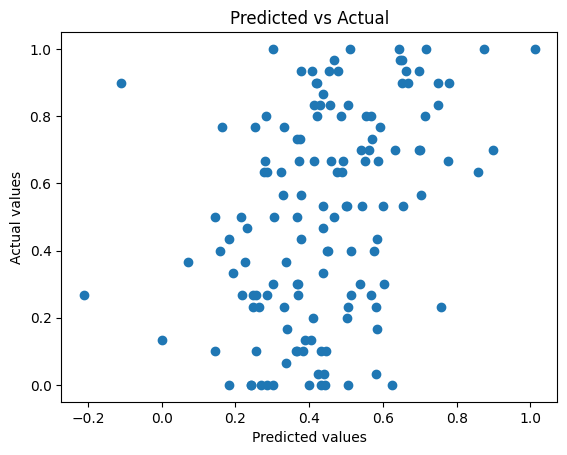

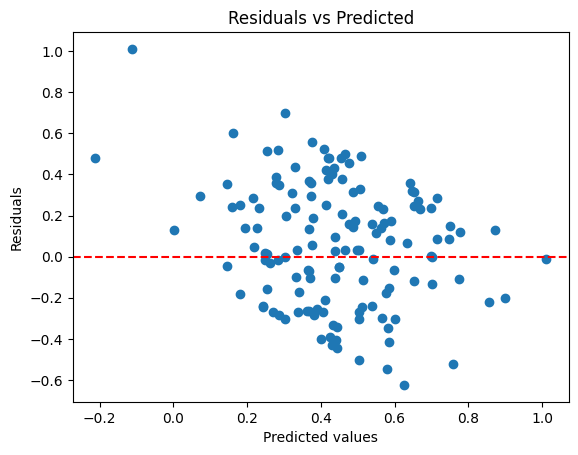

In [58]:
## Linear Regression Assumption 

import matplotlib.pyplot as plt

y_pred = linear_reg.predict(X_test_scaled)
plt.scatter(y_pred, y_test)
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.title("Predicted vs Actual")
plt.show()

residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()


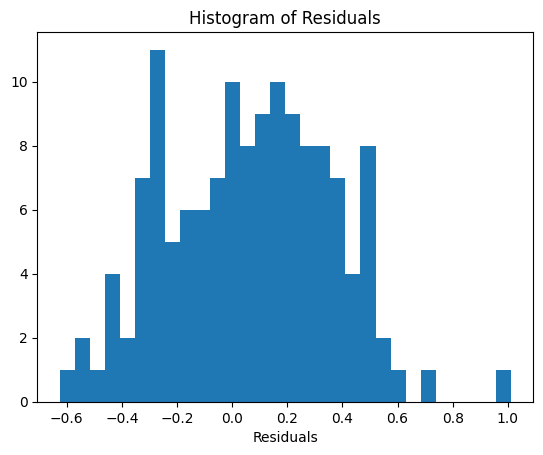

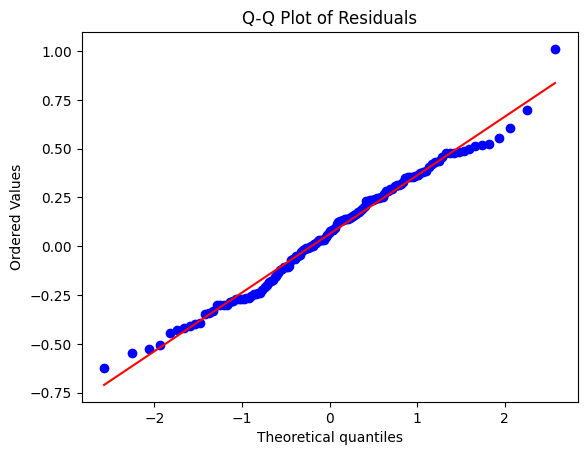

In [59]:
import scipy.stats as stats

plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.show()

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

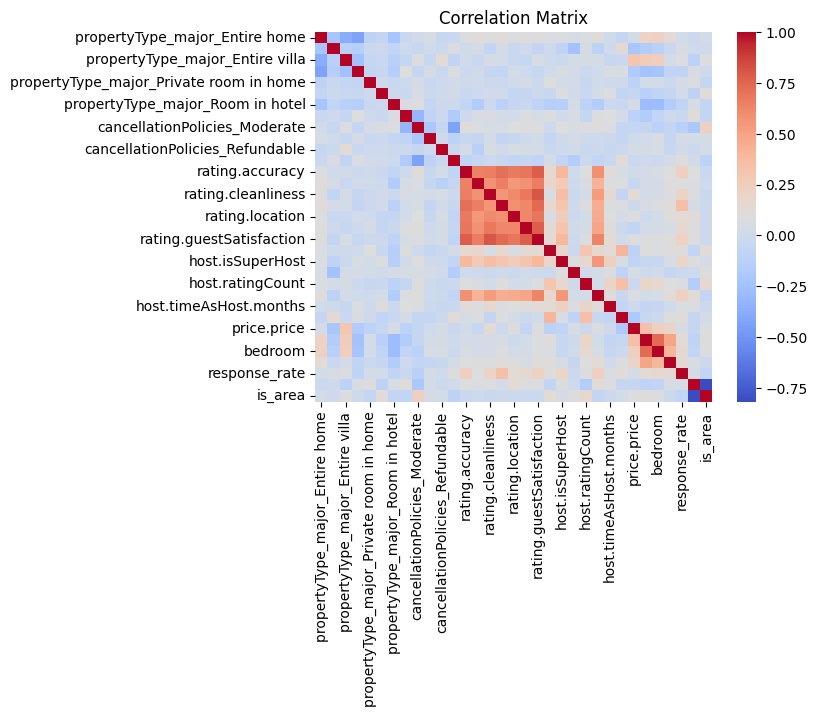

In [63]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
# If your features are in a DataFrame:
X_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
corr_matrix = X_df.corr()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [64]:
# VIF calculation
vif_data = pd.DataFrame()
vif_data["feature"] = X_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
print(vif_data)

                                      feature       VIF
0              propertyType_major_Entire home  7.422822
1       propertyType_major_Entire rental unit  3.083941
2             propertyType_major_Entire villa  5.204998
3                    propertyType_major_Other  5.819359
4     propertyType_major_Private room in home  1.478306
5   propertyType_major_Private room in ryokan  1.302612
6            propertyType_major_Room in hotel  3.159145
7               cancellationPolicies_Flexible  1.647970
8               cancellationPolicies_Moderate  2.259684
9         cancellationPolicies_Non-refundable  1.284839
10            cancellationPolicies_Refundable  1.102420
11                cancellationPolicies_Strict  1.773938
12                            rating.accuracy  3.565421
13                            rating.checking  2.455072
14                         rating.cleanliness  3.375621
15                       rating.communication  3.200847
16                            rating.location  2

## Follow up Task 2

Before we move on the model evaluation, this linear regression asumption excersize revealed further potential preprocessing requirements like trming outliner, PCA because of linearity plot and VIF.

### Optional Task 3: Model Preliminary Evaluation (This is an important part of final project. You can choose to complete this task (Task 3) this week, or you can finish it next week)

**Objective**: Conduct an initial performance evaluation of the trained models using the test set. This assessment will offer insights into each model's effectiveness and identify potential areas for improvement.

**Instructions:**

- **Evaluate Using Test Set**: Assess the performance of each trained model on the test set. This direct evaluation approach helps in understanding how the models might perform in real-world scenarios.


- **Selection of Evaluation Metrics:**

   - **For regression tasks**, consider using metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared to gauge the models' accuracy and fit.
   
   - **For classification tasks**, utilize metrics like accuracy, precision, recall, F1-score, and the area under the ROC curve (AUC-ROC) to evaluate the models' ability to correctly classify instances.
   
*Note: For implementing these metrics, you could refer to the 'Evaluation Metrics and Scoring' lectures and Jupyter notebook provided in Week 6.*

<span style="color:green;">**Document Performance and Initial Analysis**:</span>

<span style="color:green;">Prepare 1-2 paragraphs that:</span>
- <span style="color:green;">Summarize the performance metrics for each model based on their evaluation on the test set. Include key metrics such as accuracy, precision, recall, F1-score for classification tasks, and MSE, RMSE, R-squared for regression tasks, as applicable.</span>


- <span style="color:green;">Provide your initial impressions on which models appear to be the best candidates for your project's objectives. Discuss any models that stand out in terms of performance or those that may require further adjustments or investigation.</span>

<span style="color:green;">This concise documentation will serve as a foundational analysis, guiding your next steps in model optimization and fine-tuning, as well as in the final evaluation of the model, both scheduled for next week.</span>